<a href="https://colab.research.google.com/github/zrsteff/DSC502-Group-1-Project/blob/main/DSC502_Group_Project_ZRS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


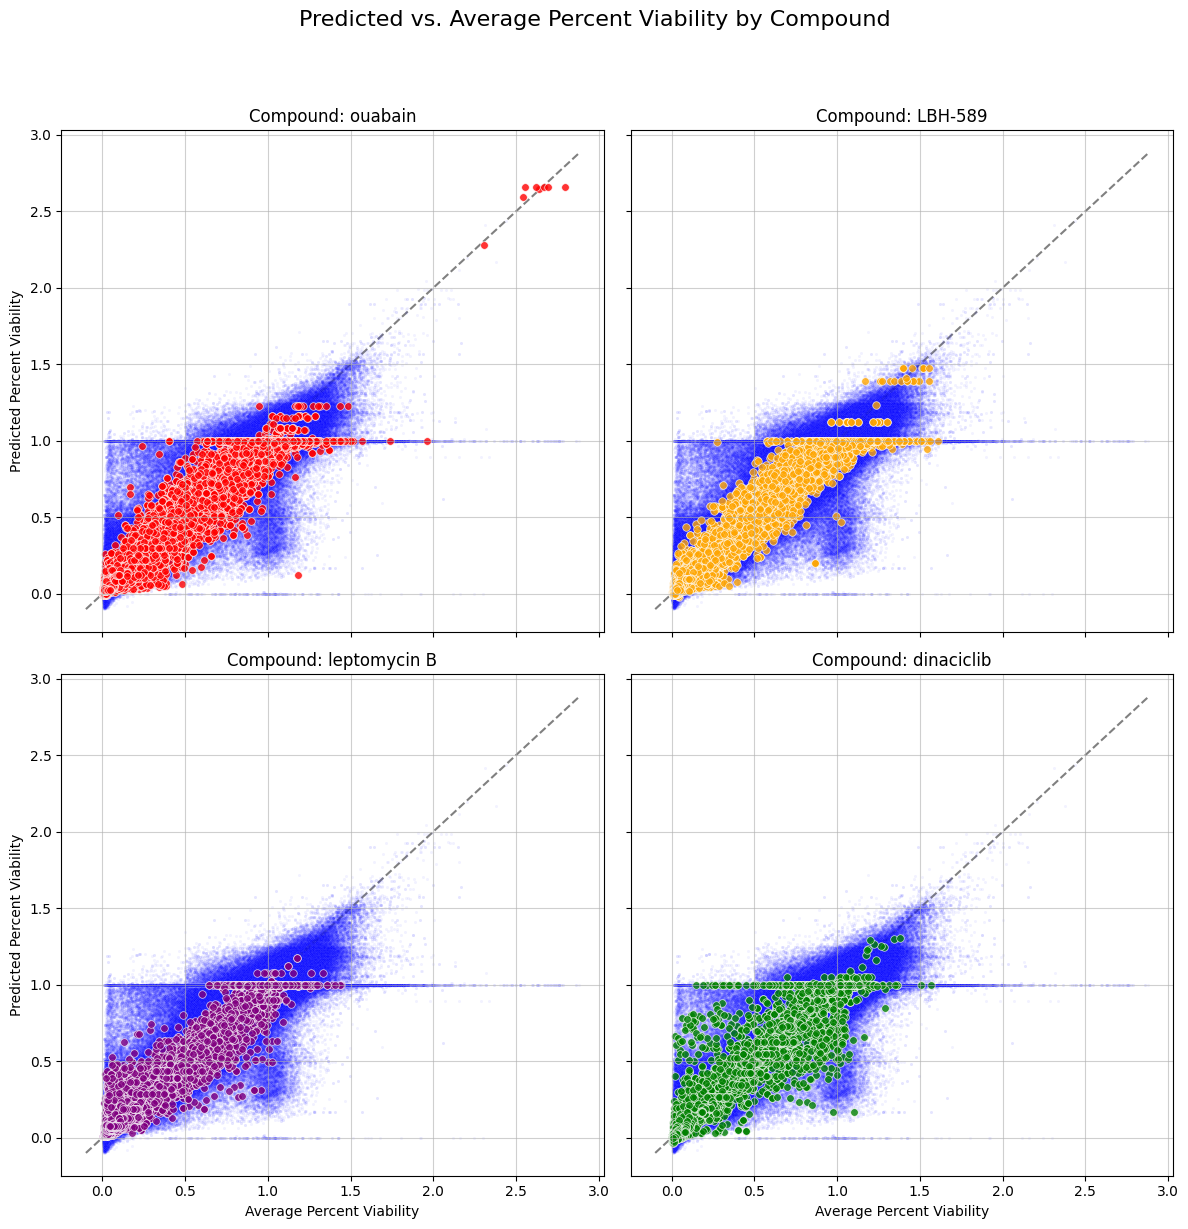

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = {
    'ouabain': 'red',
    'LBH-589': 'orange',
    'leptomycin B': 'purple',
    'dinaciclib': 'green',
    'Other Compounds': 'blue'
}

other_compounds_data = plot_data[plot_data['compound_category'] == 'Other Compounds']
selected_compounds_data = plot_data[plot_data['compound_category'] != 'Other Compounds']

min_val = plot_data[['cpd_avg_pv', 'cpd_pred_pv']].min().min()
max_val = plot_data[['cpd_avg_pv', 'cpd_pred_pv']].max().max()

num_compounds = len(selected_compound_names)
n_cols = 2
n_rows = (num_compounds + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 6), sharex=True, sharey=True)
axes = axes.flatten()

for i, compound_name in enumerate(selected_compound_names):
    ax = axes[i]

    sns.scatterplot(
        data=other_compounds_data,
        x='cpd_avg_pv',
        y='cpd_pred_pv',
        color=colors['Other Compounds'],
        alpha=0.05,
        s=5,
        ax=ax,
        legend=False
    )

    subset = selected_compounds_data[selected_compounds_data['compound_category'] == compound_name]
    sns.scatterplot(
        data=subset,
        x='cpd_avg_pv',
        y='cpd_pred_pv',
        color=colors[compound_name],
        alpha=0.8,
        s=30,
        edgecolor='w',
        linewidth=0.5,
        ax=ax,
        legend=False
    )

    ax.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', label='Perfect Agreement (y=x)', zorder=0)

    ax.set_title(f'Compound: {compound_name}')
    ax.set_xlabel('Average Percent Viability')
    ax.set_ylabel('Predicted Percent Viability')
    ax.grid(True, alpha=0.6)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Predicted vs. Average Percent Viability by Compound', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

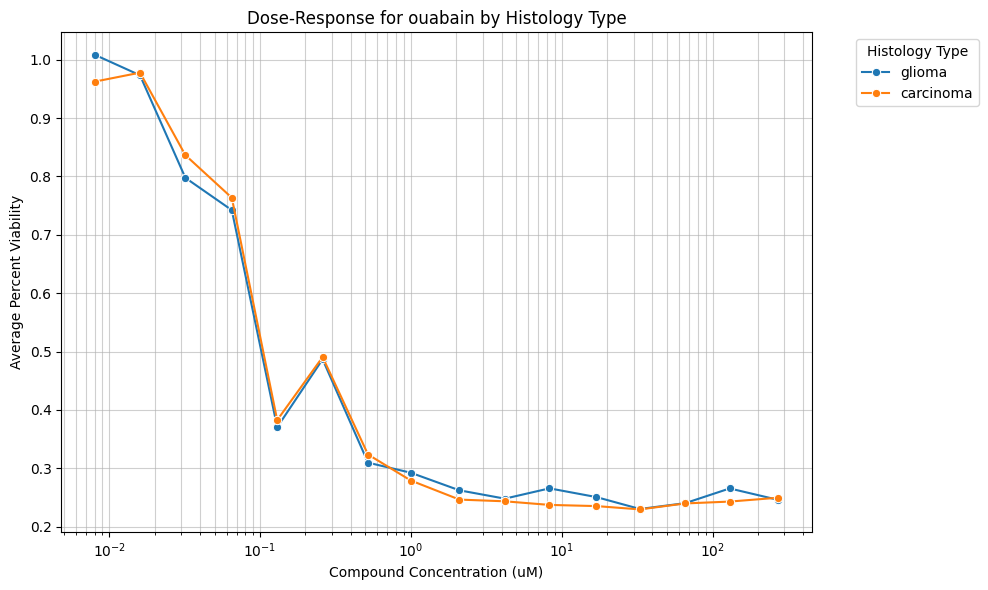

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

single_compound_name = 'ouabain'
single_compound_id = compound_df[compound_df['cpd_name'] == single_compound_name]['master_cpd_id'].iloc[0]

compound_histology_df = final_merged_df[
    (final_merged_df['master_cpd_id'] == single_compound_id) &
    (final_merged_df['ccle_primary_hist'].isin(selected_histology_types))
].copy()
compound_histology_df['ccle_primary_hist_cleaned'] = compound_histology_df['ccle_primary_hist'].str.replace('_', ' ')

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=compound_histology_df,
    x='cpd_conc_umol',
    y='cpd_avg_pv',
    hue='ccle_primary_hist_cleaned',
    marker='o',
    errorbar=None
)
plt.xscale('log')
plt.xlabel('Compound Concentration (uM)')
plt.ylabel('Average Percent Viability')
plt.title(f'Dose-Response for {single_compound_name} by Histology Type')
plt.legend(title='Histology Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

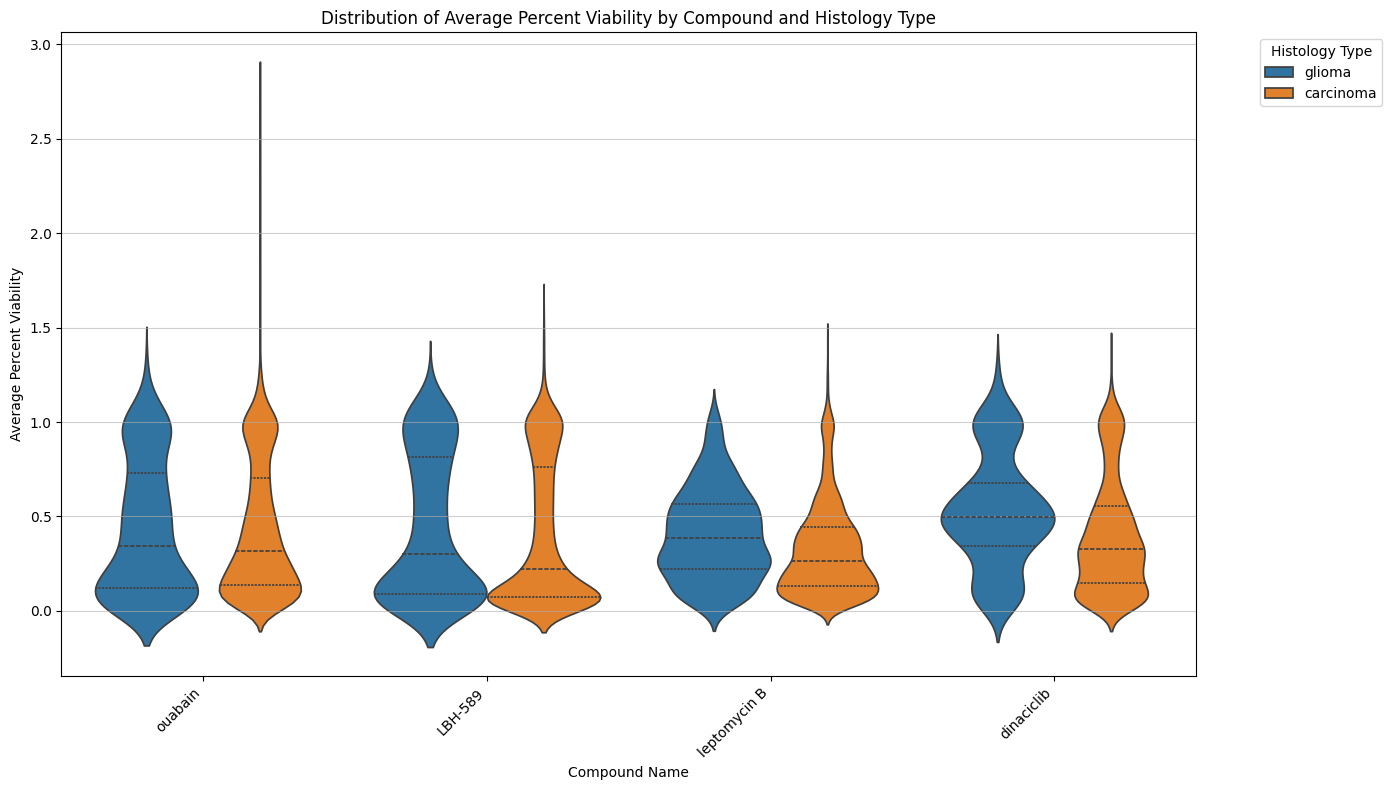

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = filtered_df.copy()
plot_df['ccle_primary_hist_cleaned'] = plot_df['ccle_primary_hist'].str.replace('_', ' ')

plt.figure(figsize=(14, 8))
sns.violinplot(
    data=plot_df,
    x='cpd_name',
    y='cpd_avg_pv',
    hue='ccle_primary_hist_cleaned',
    inner='quartile',
    palette='tab10'
)
plt.xlabel('Compound Name')
plt.ylabel('Average Percent Viability')
plt.title('Distribution of Average Percent Viability by Compound and Histology Type')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Histology Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.6)
plt.tight_layout()
plt.show()

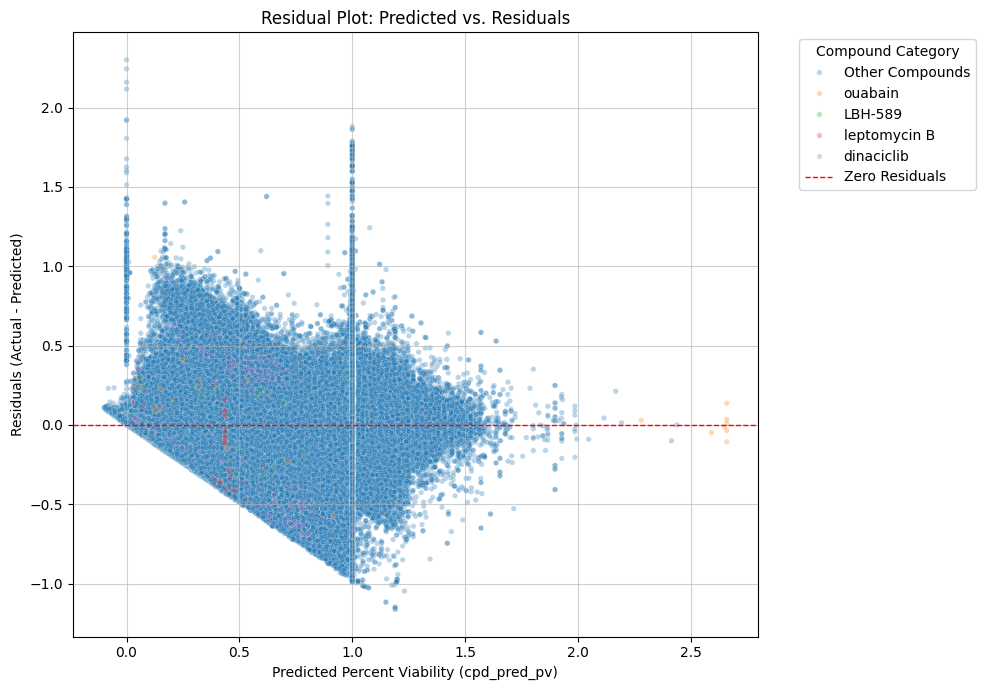

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data['residual'] = plot_data['cpd_avg_pv'] - plot_data['cpd_pred_pv']

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_data,
    x='cpd_pred_pv',
    y='residual',
    hue='compound_category',
    alpha=0.3,
    s=15,
    legend='brief'
)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Residuals')
plt.xlabel('Predicted Percent Viability (cpd_pred_pv)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot: Predicted vs. Residuals')
plt.legend(title='Compound Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

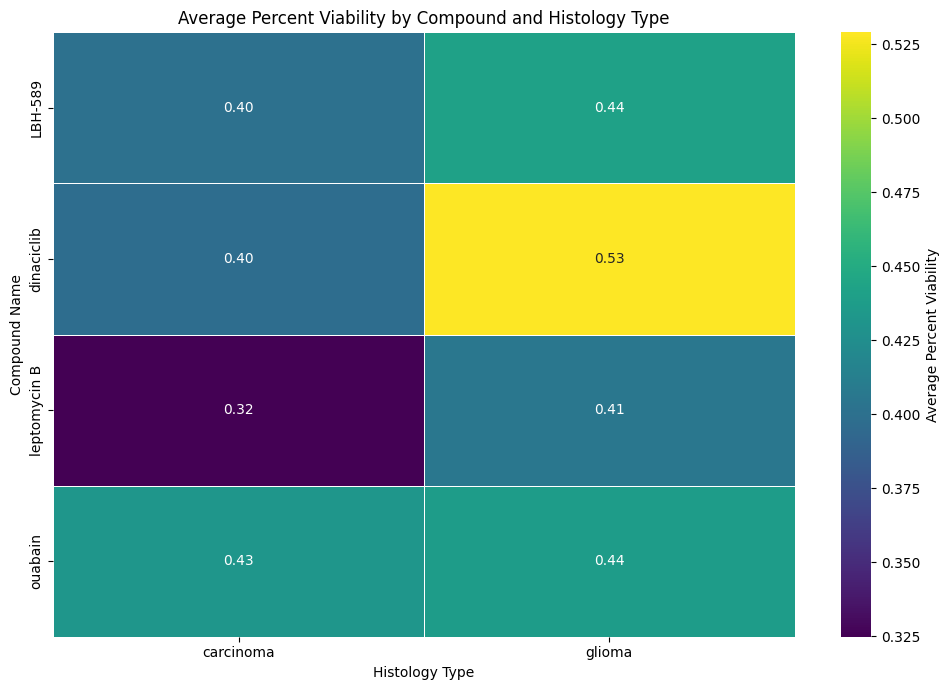

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

heatmap_data = filtered_df.groupby(['cpd_name', 'ccle_primary_hist'])['cpd_avg_pv'].mean().unstack()
heatmap_data.columns = heatmap_data.columns.str.replace('_', ' ')

plt.figure(figsize=(10, 7))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Average Percent Viability'}
)
plt.xlabel('Histology Type')
plt.ylabel('Compound Name')
plt.title('Average Percent Viability by Compound and Histology Type')
plt.tight_layout()
plt.show()

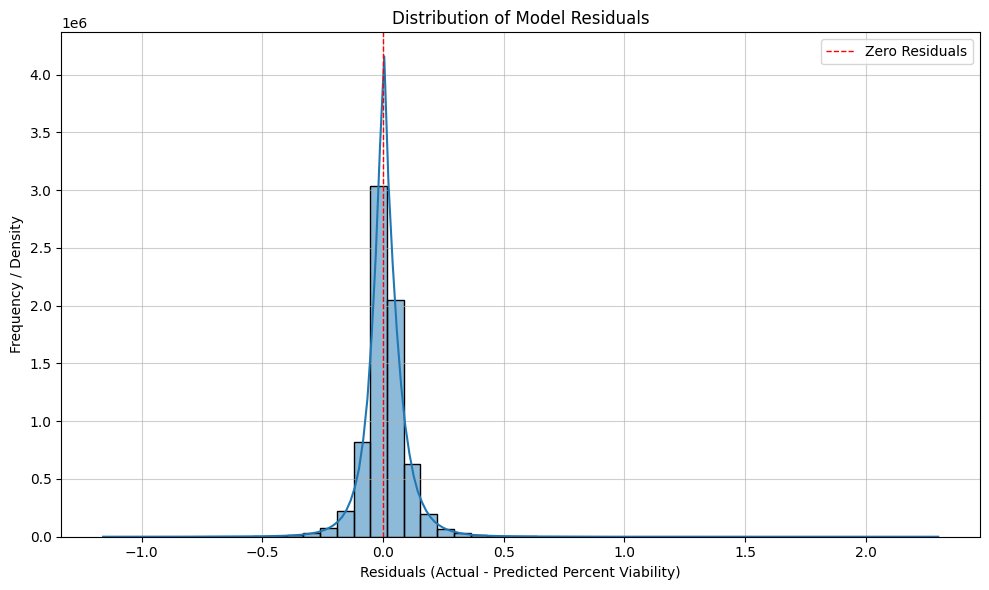

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(plot_data['residual'], bins=50, kde=True)
plt.xlabel('Residuals (Actual - Predicted Percent Viability)')
plt.ylabel('Frequency / Density')
plt.title('Distribution of Model Residuals')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='Zero Residuals')
plt.legend()
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

In [49]:
selected_compound_names = ['ouabain', 'LBH-589', 'leptomycin B', 'dinaciclib']
selected_histology_types = ['glioma', 'carcinoma', 'lymphoid neoplasm']

selected_cpd_ids = compound_df[compound_df['cpd_name'].isin(selected_compound_names)]['master_cpd_id'].unique()

filtered_df = final_merged_df[
    (final_merged_df['master_cpd_id'].isin(selected_cpd_ids)) &
    (final_merged_df['ccle_primary_hist'].isin(selected_histology_types))
].copy()

filtered_df = pd.merge(filtered_df, compound_df[['master_cpd_id', 'cpd_name']], on='master_cpd_id', how='left')

print(f"Number of unique compounds selected: {len(selected_cpd_ids)}")
print(f"Selected compound IDs: {selected_cpd_ids.tolist()}")
print(f"Number of unique histology types selected: {len(selected_histology_types)}")

print("\nFiltered DataFrame Info:")
filtered_df.info()
display(filtered_df.head())

Number of unique compounds selected: 4
Selected compound IDs: [37190, 54210, 660086, 687578]
Number of unique histology types selected: 3

Filtered DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34555 entries, 0 to 34554
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   experiment_id      34555 non-null  int64  
 1   cpd_pv_errorbar    34555 non-null  float64
 2   cpd_pred_pv        34555 non-null  float64
 3   cpd_avg_pv         34555 non-null  float64
 4   cpd_conc_umol      34555 non-null  float64
 5   master_cpd_id      34555 non-null  int64  
 6   master_ccl_id      34555 non-null  int64  
 7   ccl_name           34555 non-null  object 
 8   ccle_primary_site  34555 non-null  object 
 9   ccle_primary_hist  34555 non-null  object 
 10  cpd_name           34555 non-null  object 
dtypes: float64(4), int64(3), object(4)
memory usage: 2.9+ MB


,experiment_id,cpd_pv_errorbar,cpd_pred_pv,cpd_avg_pv,cpd_conc_umol,master_cpd_id,master_ccl_id,ccl_name,ccle_primary_site,ccle_primary_hist,cpd_name
0,1,0.0,1.0000,1.2880,0.0081,37190,130,CAS1,central_nervous_system,glioma,ouabain
1,1,0.0,1.0000,1.3140,0.0160,37190,130,CAS1,central_nervous_system,glioma,ouabain
2,1,0.0,1.0000,1.0270,0.0320,37190,130,CAS1,central_nervous_system,glioma,ouabain
3,1,0.0,0.2827,0.2837,0.1300,37190,130,CAS1,central_nervous_system,glioma,ouabain
4,1,0.0,0.2823,0.4262,0.2600,37190,130,CAS1,central_nervous_system,glioma,ouabain


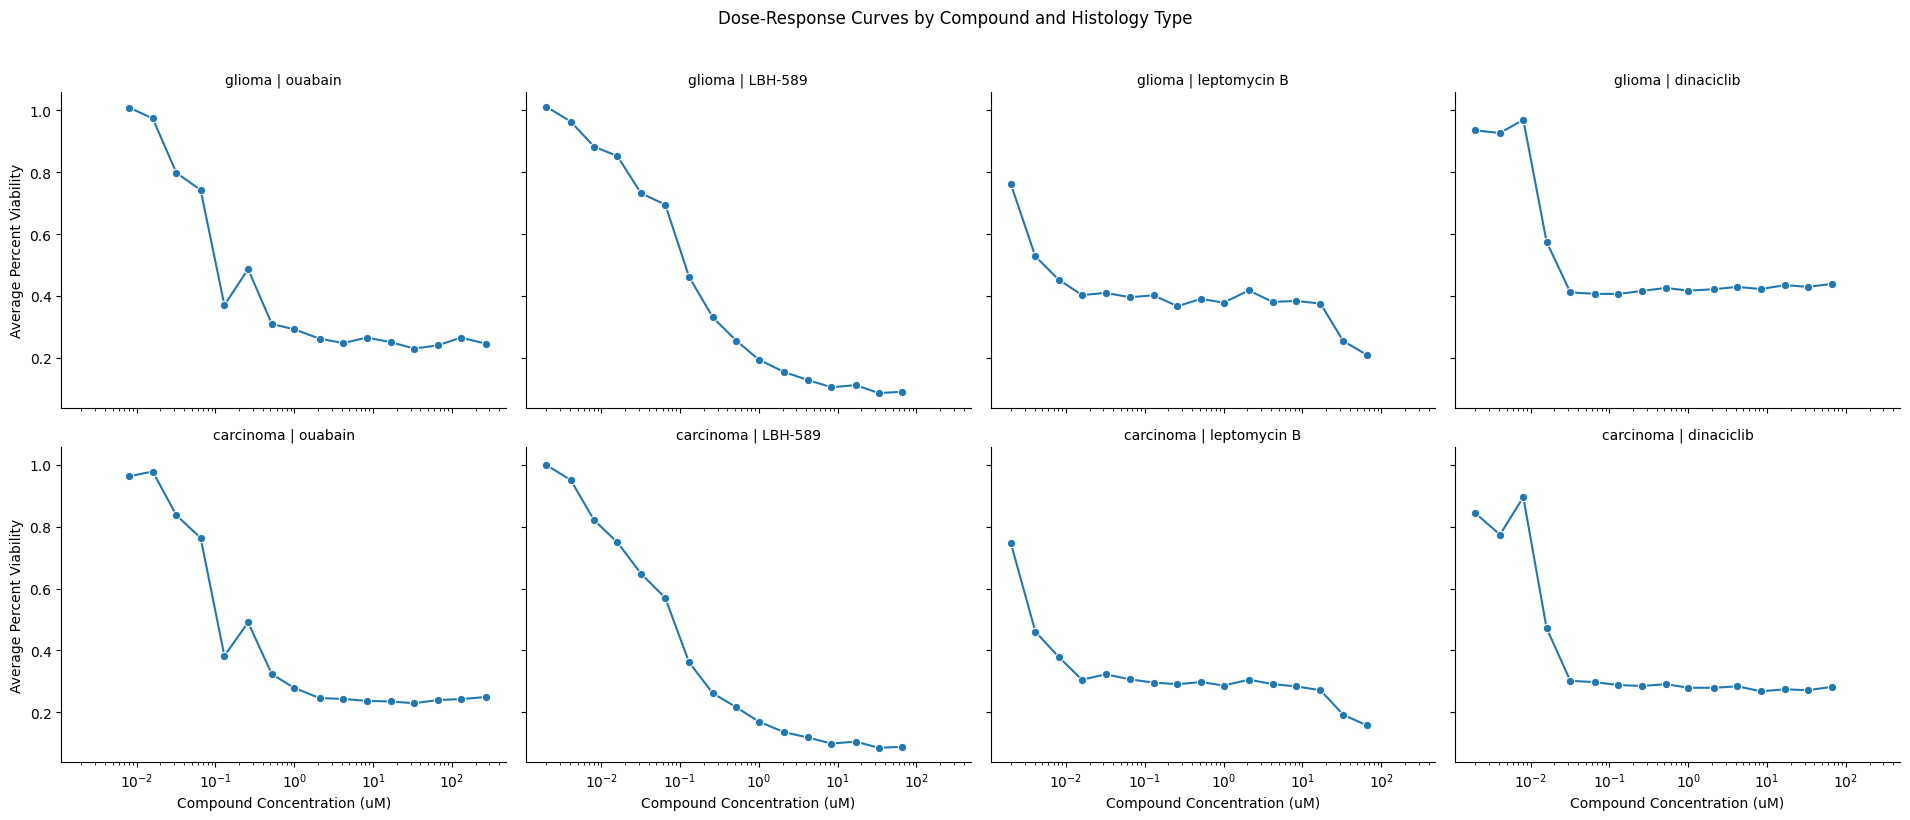

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = filtered_df.copy()
plot_df['ccle_primary_hist_cleaned'] = plot_df['ccle_primary_hist'].str.replace('_', ' ')

g = sns.relplot(
    data=plot_df,
    x='cpd_conc_umol',
    y='cpd_avg_pv',
    col='cpd_name',
    row='ccle_primary_hist_cleaned',
    kind='line',
    marker='o',
    errorbar=None,
    height=4, aspect=1.2,
    facet_kws={'sharex': True, 'sharey': True}
)

g.set(xscale='log')
g.set_axis_labels('Compound Concentration (uM)', 'Average Percent Viability')
g.set_titles(col_template='{col_name}', row_template='{row_name}')
g.fig.suptitle('Dose-Response Curves by Compound and Histology Type', y=1.02)
g.tight_layout()
plt.show()

In [51]:
compound_meta_path = '/content/drive/My Drive/DSC502ProjectData/v20.meta.per_compound.txt'
compound_df = pd.read_csv(compound_meta_path, sep='\t')

print("Compound Metadata Info:")
compound_df.info()
display(compound_df.head())

Compound Metadata Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   master_cpd_id                   545 non-null    int64  
 1   cpd_name                        545 non-null    object 
 2   broad_cpd_id                    545 non-null    object 
 3   top_test_conc_umol              545 non-null    float64
 4   cpd_status                      545 non-null    object 
 5   inclusion_rationale             545 non-null    object 
 6   gene_symbol_of_protein_target   415 non-null    object 
 7   target_or_activity_of_compound  545 non-null    object 
 8   source_name                     495 non-null    object 
 9   source_catalog_id               359 non-null    object 
 10  cpd_smiles                      545 non-null    object 
dtypes: float64(1), int64(1), object(9)
memory usage: 47.0+ KB


,master_cpd_id,cpd_name,broad_cpd_id,top_test_conc_umol,cpd_status,inclusion_rationale,gene_symbol_of_protein_target,target_or_activity_of_compound,source_name,source_catalog_id,cpd_smiles
0,1788,CIL55,BRD-K46556387,10.0,probe,pilot-set,NaN,screening hit,Columbia University,NaN,CN(C)CCNC(=O)c1cc2CSc3cc(Cl)ccc3-c2s1
1,3588,BRD4132,BRD-K86574132,160.0,probe,chromatin;pilot-set,NaN,screening hit,ChemDiv Inc.,4998-1380,CC(C)N1C(=O)S\C(=C\c2ccc(Sc3nc4ccccc4[nH]3)o2)...
2,12877,BRD6340,BRD-K35716340,33.0,probe,chromatin;pilot-set,NaN,screening hit,ChemDiv Inc.,1988-0090,C(Cn1c2ccccc2c2ccccc12)c1nc2ccccc2[nH]1
3,17712,ML006,BRD-K89692698,530.0,probe,pilot-set,S1PR3,agonist of sphingosine 1-phosphate receptor 3,Enamine Ltd.,Z1037336336,C1CN(CCO1)c1nnc(-c2ccccc2)c(n1)-c1ccccc1
4,18311,Bax channel blocker,BRD-A18763547,33.0,probe,pilot-set,BAX,inhibitor of BAX-mediated mitochondrial cytoch...,Maybridge,RJC01737,OC(CN1CCNCC1)Cn1c2ccc(Br)cc2c2cc(Br)ccc12


In [ ]:
!ls '/content/drive/My Drive/DSC502ProjectData'

CTRPv2.0._COLUMNS.xlsx	      v20.data.per_cpd_pre_qc.txt
CTRPv2.0._INFORMER_SET.xlsx   v20.data.per_cpd_well.txt
CTRPv2.0._README.docx	      v20.meta.media_comp.txt
MANIFEST.txt		      v20.meta.per_assay_plate.txt
v20._COLUMNS.txt	      v20.meta.per_cell_line.txt
v20.data.curves_post_qc.txt   v20.meta.per_compound.txt
v20.data.per_cpd_avg.txt      v20.meta.per_experiment.txt
v20.data.per_cpd_post_qc.txt  v20._README.txt


In [52]:
file_path = '/content/drive/My Drive/DSC502ProjectData/v20.data.per_cpd_post_qc.txt'


In [53]:
import pandas as pd
df = pd.read_csv(file_path, sep='\t')
display(df.head())

,experiment_id,cpd_pv_errorbar,cpd_pred_pv,cpd_avg_pv,cpd_conc_umol,master_cpd_id
0,1,0.000058,1.0,0.9303,0.00030,1788
1,1,0.000058,1.0,0.8337,0.00061,1788
2,1,0.000058,1.0,1.0460,0.00120,1788
3,1,0.000058,1.0,1.0910,0.00240,1788
4,1,0.000058,1.0,1.0190,0.00490,1788


In [54]:
print("Data types of all columns:")
df.info()

print("\nDescriptive statistics for all columns:")
display(df.describe())

print("\nDescriptive statistics for 'cpd_avg_pv' and 'cpd_conc_umol':")
display(df[['cpd_avg_pv', 'cpd_conc_umol']].describe())

Data types of all columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6171005 entries, 0 to 6171004
Data columns (total 6 columns):
 #   Column           Dtype  
---  ------           -----  
 0   experiment_id    int64  
 1   cpd_pv_errorbar  float64
 2   cpd_pred_pv      float64
 3   cpd_avg_pv       float64
 4   cpd_conc_umol    float64
 5   master_cpd_id    int64  
dtypes: float64(4), int64(2)
memory usage: 282.5 MB

Descriptive statistics for all columns:


,experiment_id,cpd_pv_errorbar,cpd_pred_pv,cpd_avg_pv,cpd_conc_umol,master_cpd_id
count,6.171005e+06,6.171005e+06,6.171005e+06,6.171005e+06,6.171005e+06,6.171005e+06
mean,4.577973e+02,8.192664e+24,8.462978e-01,8.555860e-01,9.837174e+00,4.557644e+05
std,2.621522e+02,2.815797e+27,2.812886e-01,3.013601e-01,3.253056e+01,2.308714e+05
min,1.000000e+00,0.000000e+00,-9.968000e-02,1.922000e-03,4.000000e-06,1.788000e+03
25%,2.280000e+02,1.488000e-06,8.271000e-01,8.016000e-01,1.600000e-02,3.747470e+05
50%,4.600000e+02,2.684000e-02,9.948000e-01,9.660000e-01,2.600000e-01,5.968680e+05
75%,6.840000e+02,8.242000e-02,1.000000e+00,1.033000e+00,4.200000e+00,6.601760e+05
max,9.070000e+02,1.672000e+30,2.659000e+00,2.881000e+00,6.000000e+02,7.101540e+05



Descriptive statistics for 'cpd_avg_pv' and 'cpd_conc_umol':


,cpd_avg_pv,cpd_conc_umol
count,6.171005e+06,6.171005e+06
mean,8.555860e-01,9.837174e+00
std,3.013601e-01,3.253056e+01
min,1.922000e-03,4.000000e-06
25%,8.016000e-01,1.600000e-02
50%,9.660000e-01,2.600000e-01
75%,1.033000e+00,4.200000e+00
max,2.881000e+00,6.000000e+02


## Visualize Dose-Response Curves

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_cpds = df['master_cpd_id'].unique()

num_compounds_to_plot = 5
sampled_cpd_ids = unique_cpds[:num_compounds_to_plot]

sampled_df = df[df['master_cpd_id'].isin(sampled_cpd_ids)]

print(f"Original DataFrame size: {len(df)} rows")
print(f"Sampled DataFrame size: {len(sampled_df)} rows for {num_compounds_to_plot} compounds.")

Original DataFrame size: 6171005 rows
Sampled DataFrame size: 56080 rows for 5 compounds.


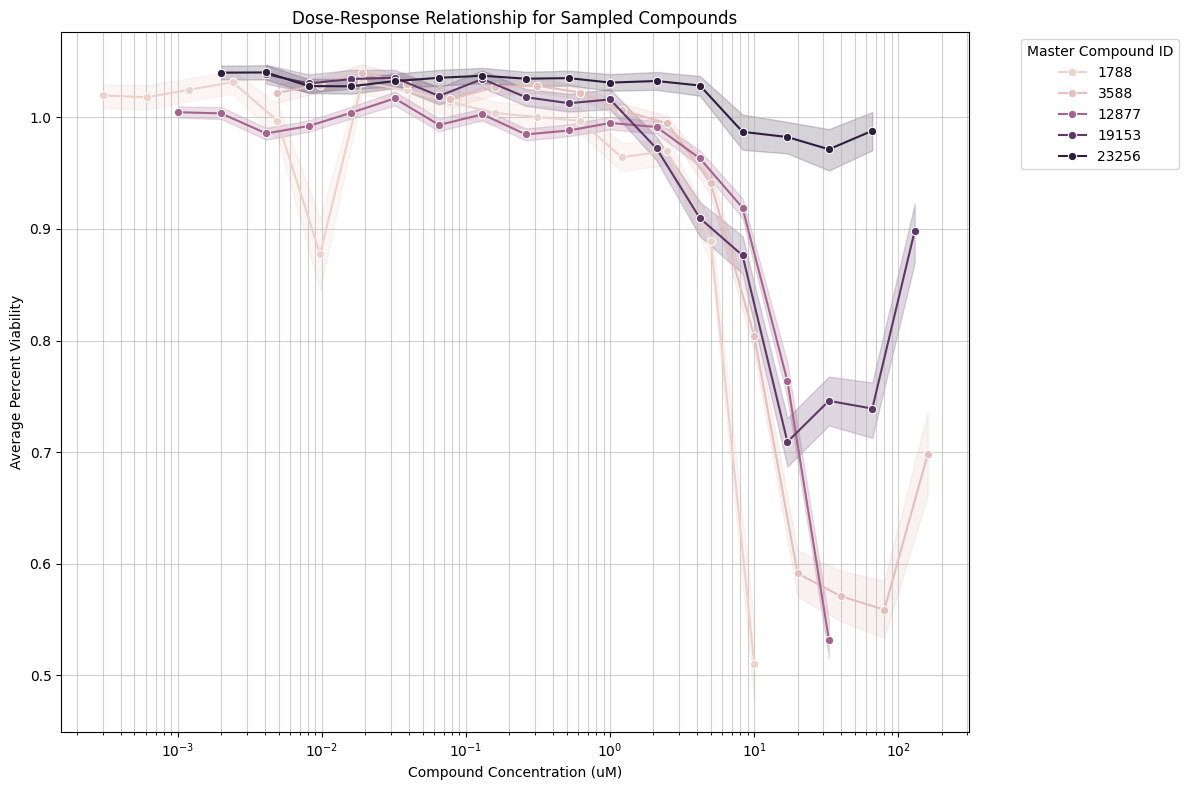

In [56]:
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=sampled_df,
    x='cpd_conc_umol',
    y='cpd_avg_pv',
    hue='master_cpd_id',
    marker='o'
)
plt.xscale('log')
plt.xlabel('Compound Concentration (uM)')
plt.ylabel('Average Percent Viability')
plt.title('Dose-Response Relationship for Sampled Compounds')
plt.legend(title='Master Compound ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

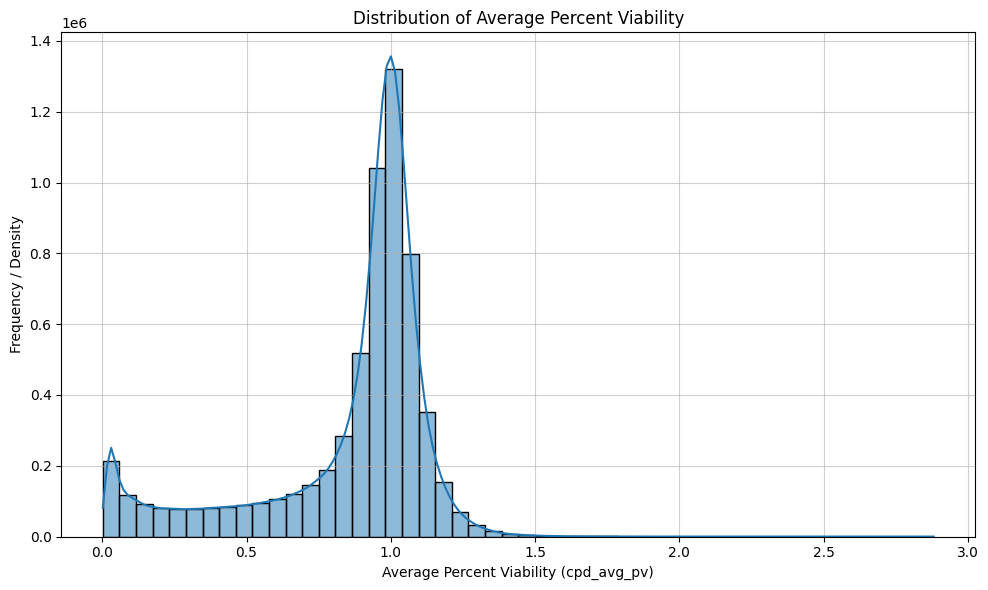

In [57]:
plt.figure(figsize=(10, 6))
sns.histplot(df['cpd_avg_pv'], bins=50, kde=True)
plt.xlabel('Average Percent Viability (cpd_avg_pv)')
plt.ylabel('Frequency / Density')
plt.title('Distribution of Average Percent Viability')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

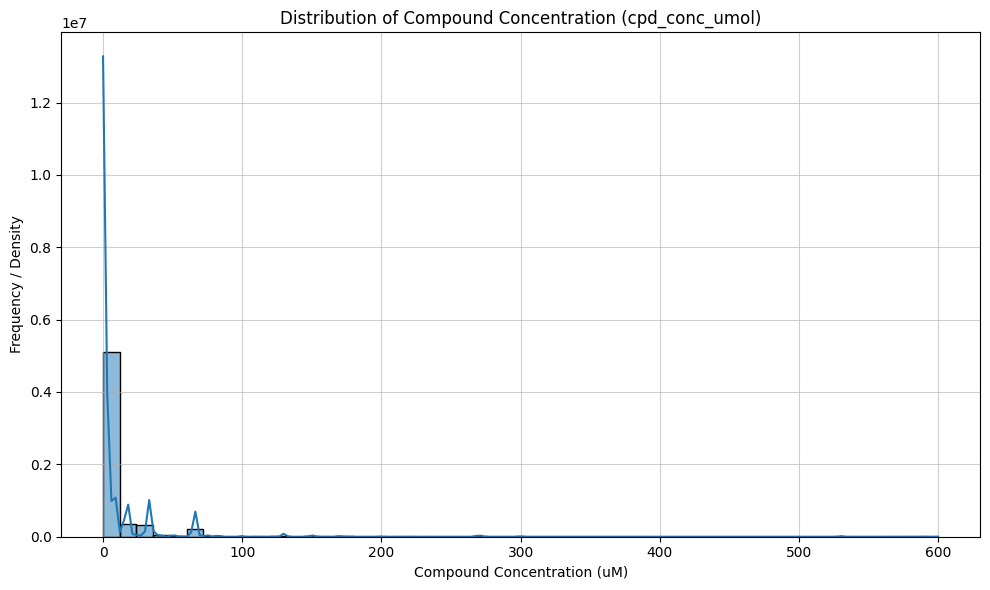

In [58]:
plt.figure(figsize=(10, 6))
sns.histplot(df['cpd_conc_umol'], bins=50, kde=True)
plt.xlabel('Compound Concentration (uM)')
plt.ylabel('Frequency / Density')
plt.title('Distribution of Compound Concentration (cpd_conc_umol)')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

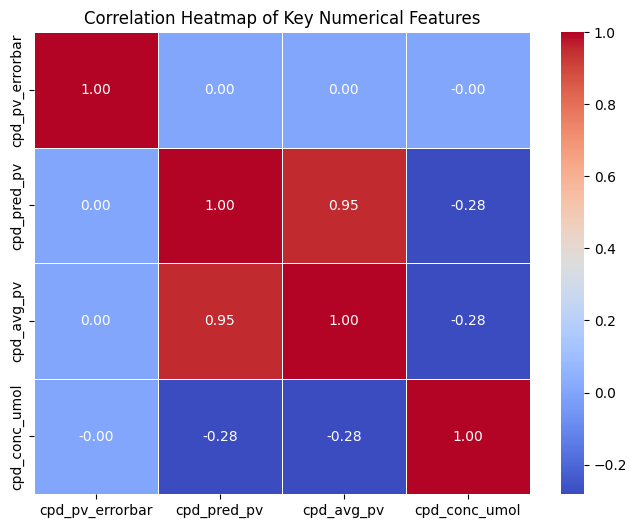

In [59]:
selected_columns = ['cpd_pv_errorbar', 'cpd_pred_pv', 'cpd_avg_pv', 'cpd_conc_umol']
correlation_matrix = df[selected_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Key Numerical Features')
plt.show()

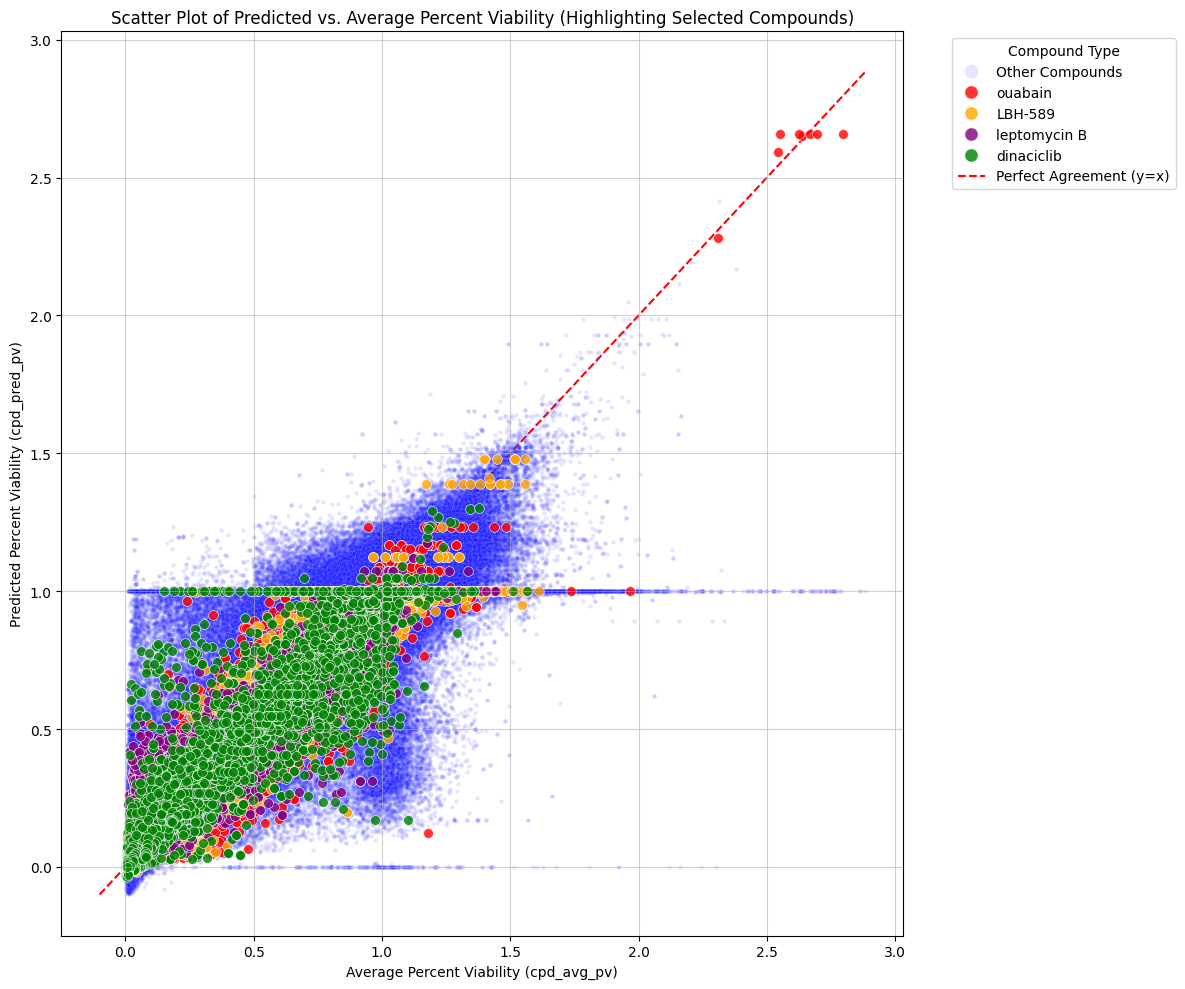

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

plot_data = final_merged_df[['cpd_avg_pv', 'cpd_pred_pv', 'master_cpd_id']].copy()

compound_name_map = compound_df[compound_df['master_cpd_id'].isin(selected_cpd_ids)].set_index('master_cpd_id')['cpd_name'].to_dict()
plot_data['compound_category'] = plot_data['master_cpd_id'].map(compound_name_map).fillna('Other Compounds')

plt.figure(figsize=(12, 10))

colors = {
    'ouabain': 'red',
    'LBH-589': 'orange',
    'leptomycin B': 'purple',
    'dinaciclib': 'green',
    'Other Compounds': 'blue'
}

other_compounds_data = plot_data[plot_data['compound_category'] == 'Other Compounds']
selected_compounds_data = plot_data[plot_data['compound_category'] != 'Other Compounds']

sns.scatterplot(
    data=other_compounds_data,
    x='cpd_avg_pv',
    y='cpd_pred_pv',
    color=colors['Other Compounds'],
    alpha=0.1,
    s=10,
    legend=False
)

for compound_name in selected_compound_names:
    subset = selected_compounds_data[selected_compounds_data['compound_category'] == compound_name]
    sns.scatterplot(
        data=subset,
        x='cpd_avg_pv',
        y='cpd_pred_pv',
        color=colors[compound_name],
        alpha=0.8,
        s=50,
        edgecolor='w',
        linewidth=0.5,
        legend=False
    )

min_val = plot_data[['cpd_avg_pv', 'cpd_pred_pv']].min().min()
max_val = plot_data[['cpd_avg_pv', 'cpd_pred_pv']].max().max()
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Agreement (y=x)', zorder=0)

plt.xlabel('Average Percent Viability (cpd_avg_pv)')
plt.ylabel('Predicted Percent Viability (cpd_pred_pv)')
plt.title('Scatter Plot of Predicted vs. Average Percent Viability (Highlighting Selected Compounds)')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Other Compounds',
           markerfacecolor=colors['Other Compounds'], markersize=10, alpha=0.1)
]

for compound_name in selected_compound_names:
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', label=compound_name,
               markerfacecolor=colors[compound_name], markersize=10, alpha=0.8)
    )

legend_elements.append(
    Line2D([0], [0], color='red', linestyle='--', label='Perfect Agreement (y=x)')
)

plt.legend(handles=legend_elements, title='Compound Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

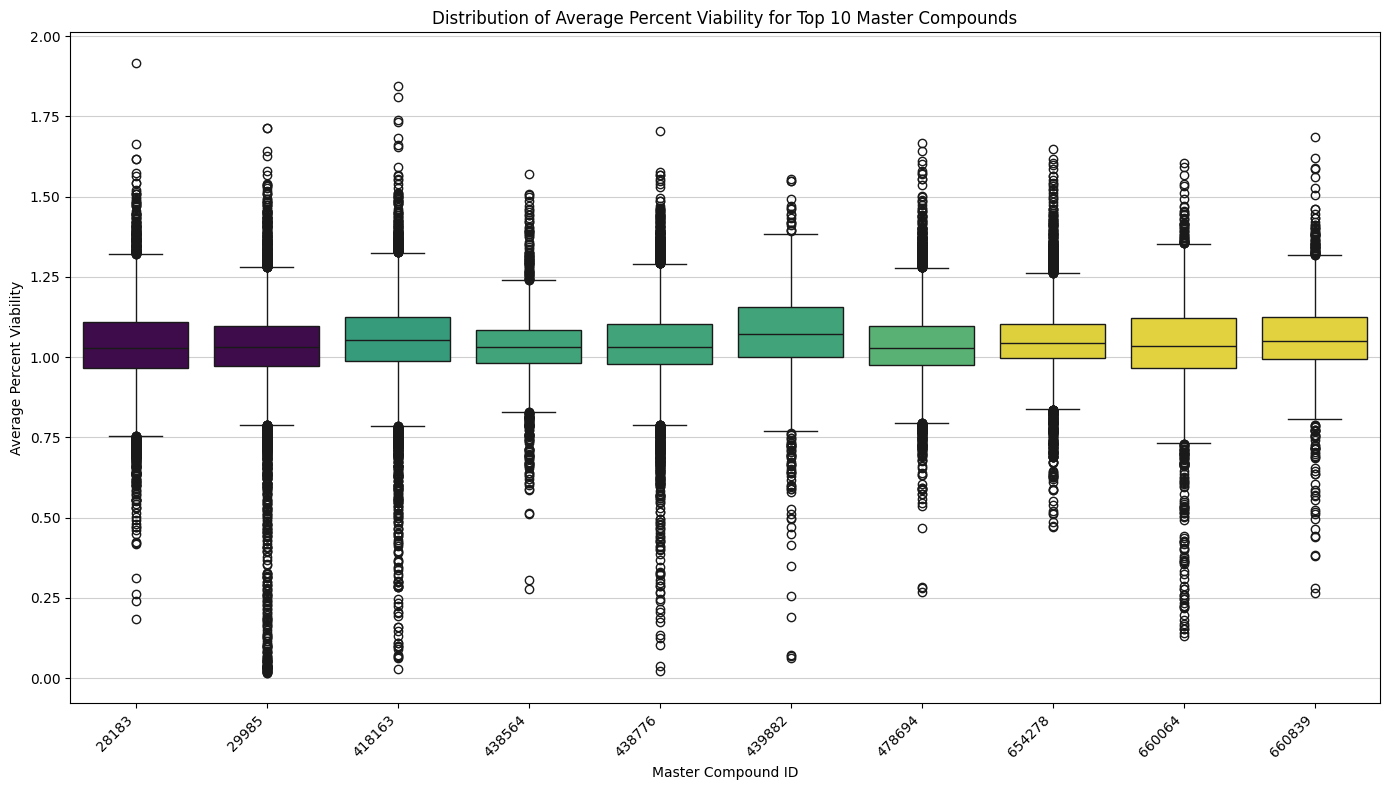

In [61]:
top_10_cpds = df.groupby('master_cpd_id')['cpd_avg_pv'].mean().nlargest(10)
top_10_cpd_ids = top_10_cpds.index
df_top_10_cpds = df[df['master_cpd_id'].isin(top_10_cpd_ids)]

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_top_10_cpds, x='master_cpd_id', y='cpd_avg_pv', hue='master_cpd_id', palette='viridis', legend=False)
plt.xlabel('Master Compound ID')
plt.ylabel('Average Percent Viability')
plt.title('Distribution of Average Percent Viability for Top 10 Master Compounds')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.6)
plt.tight_layout()
plt.show()

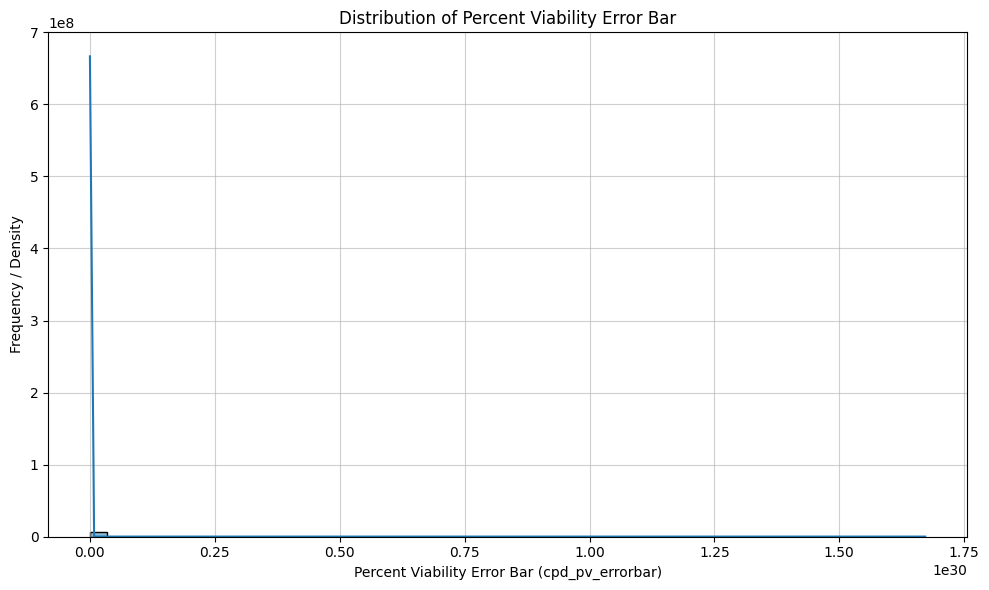

In [62]:
plt.figure(figsize=(10, 6))
sns.histplot(df['cpd_pv_errorbar'], bins=50, kde=True)
plt.xlabel('Percent Viability Error Bar (cpd_pv_errorbar)')
plt.ylabel('Frequency / Density')
plt.title('Distribution of Percent Viability Error Bar')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

Plotting dose-response curves for experiment ID: 311


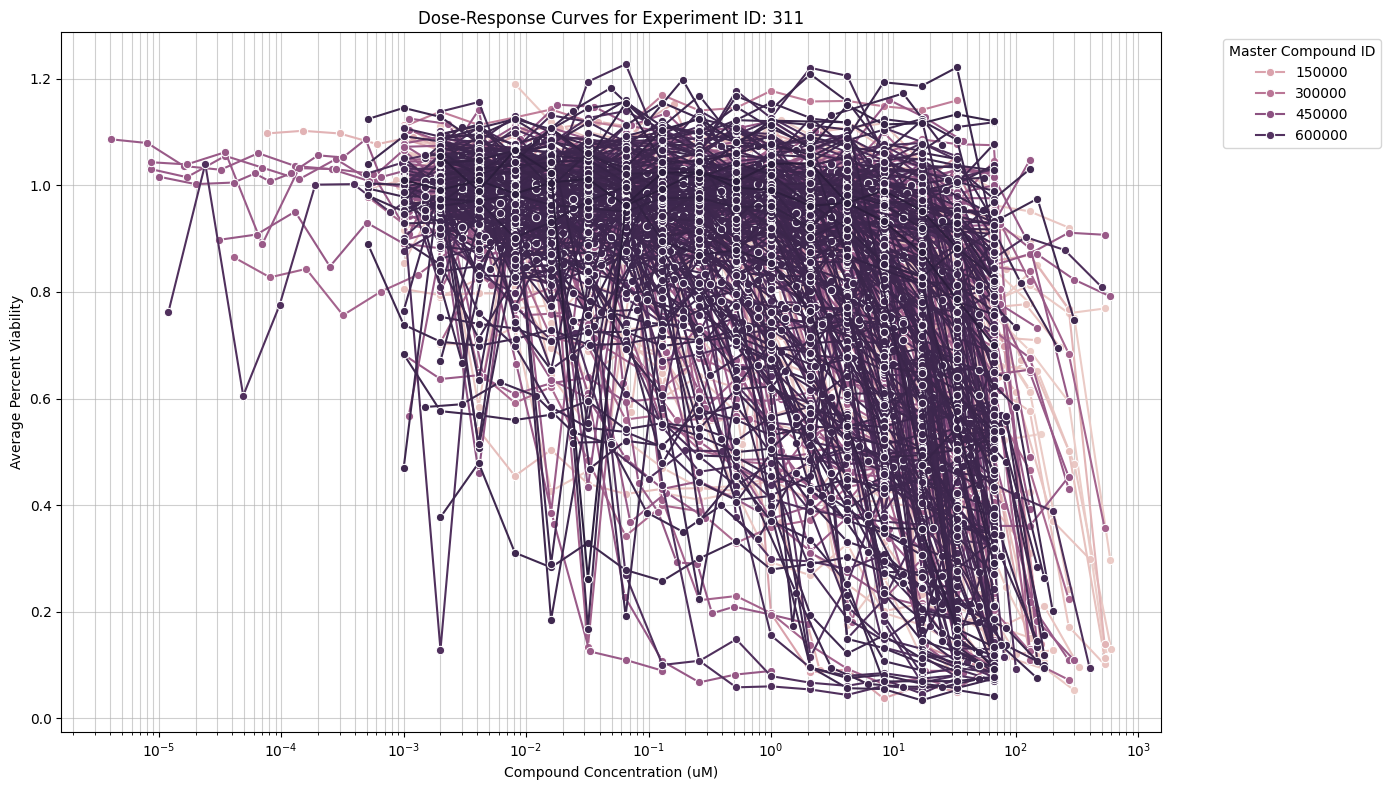

In [63]:
selected_experiment_id = df['experiment_id'].sample(1).iloc[0]
print(f"Plotting dose-response curves for experiment ID: {selected_experiment_id}")

df_experiment = df[df['experiment_id'] == selected_experiment_id]

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df_experiment,
    x='cpd_conc_umol',
    y='cpd_avg_pv',
    hue='master_cpd_id',
    marker='o',
    errorbar=None
)
plt.xscale('log')
plt.xlabel('Compound Concentration (uM)')
plt.ylabel('Average Percent Viability')
plt.title(f'Dose-Response Curves for Experiment ID: {selected_experiment_id}')
plt.legend(title='Master Compound ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

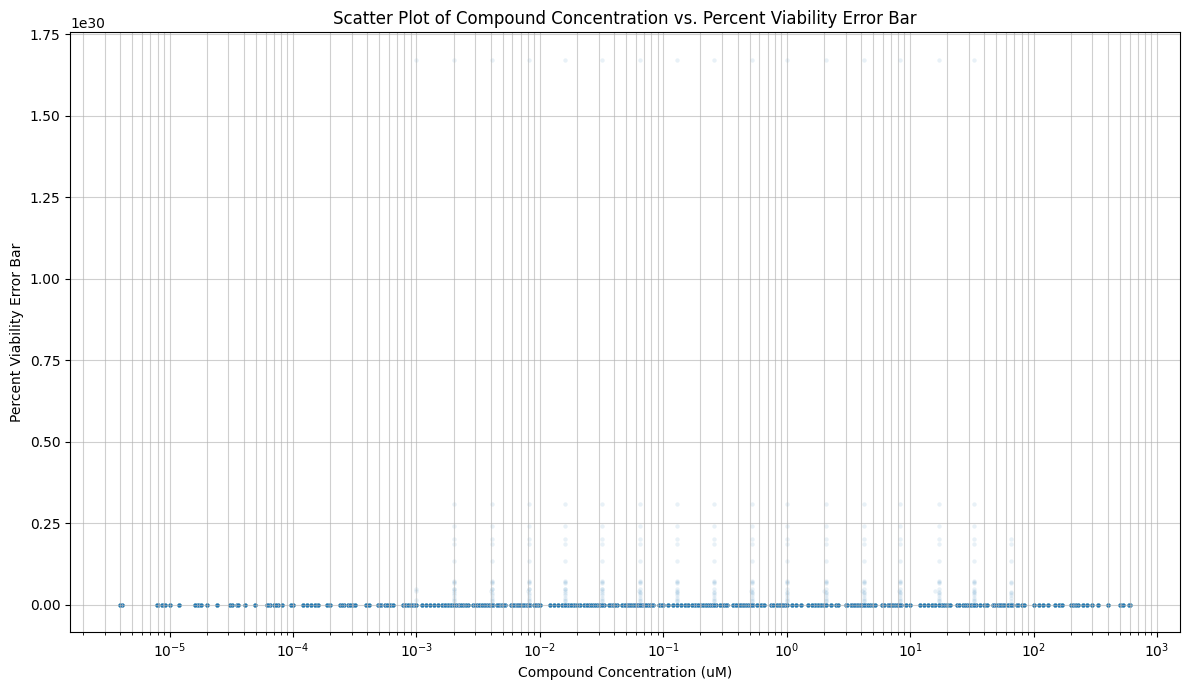

In [64]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='cpd_conc_umol', y='cpd_pv_errorbar', alpha=0.1, s=10)
plt.xscale('log')
plt.xlabel('Compound Concentration (uM)')
plt.ylabel('Percent Viability Error Bar')
plt.title('Scatter Plot of Compound Concentration vs. Percent Viability Error Bar')
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

In [65]:
cell_line_meta_path = '/content/drive/My Drive/DSC502ProjectData/v20.meta.per_cell_line.txt'
experiment_meta_path = '/content/drive/My Drive/DSC502ProjectData/v20.meta.per_experiment.txt'

cell_line_df = pd.read_csv(cell_line_meta_path, sep='\t')
experiment_df = pd.read_csv(experiment_meta_path, sep='\t')

print("Cell Line Metadata Info:")
cell_line_df.info()
display(cell_line_df.head())

print("\nExperiment Metadata Info:")
experiment_df.info()
display(experiment_df.head())

Cell Line Metadata Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107 entries, 0 to 1106
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   master_ccl_id        1107 non-null   int64 
 1   ccl_name             1107 non-null   object
 2   ccl_availability     1107 non-null   object
 3   ccle_primary_site    1045 non-null   object
 4   ccle_primary_hist    1032 non-null   object
 5   ccle_hist_subtype_1  779 non-null    object
dtypes: int64(1), object(5)
memory usage: 52.0+ KB


,master_ccl_id,ccl_name,ccl_availability,ccle_primary_site,ccle_primary_hist,ccle_hist_subtype_1
0,1,697,ccle;public,haematopoietic_and_lymphoid_tissue,lymphoid_neoplasm,acute_lymphoblastic_B_cell_leukaemia
1,3,5637,ccle;public,urinary_tract,carcinoma,NaN
2,4,2313287,ccle;public,stomach,carcinoma,adenocarcinoma
3,5,1321N1,ccle,central_nervous_system,glioma,astrocytoma
4,6,143B,ccle,bone,osteosarcoma,NaN



Experiment Metadata Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   experiment_id    1061 non-null   int64  
 1   run_id           1061 non-null   object 
 2   experiment_date  1061 non-null   int64  
 3   culture_media    1061 non-null   object 
 4   baseline_signal  1061 non-null   float64
 5   cells_per_well   1061 non-null   int64  
 6   growth_mode      1061 non-null   object 
 7   snp_fp_status    1061 non-null   object 
 8   master_ccl_id    1061 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 74.7+ KB


,experiment_id,run_id,experiment_date,culture_media,baseline_signal,cells_per_well,growth_mode,snp_fp_status,master_ccl_id
0,1,7024-01-A01-02-01,20120501,DMEM001,0.2225,500,adherent,SNP-matched-reference,130
1,2,7024-01-A01-02-01,20120501,DMEM001,0.2225,500,adherent,SNP-matched-reference,569
2,3,7024-01-A01-02-01,20120501,RPMI001,0.1195,500,adherent,SNP-matched-reference,682
3,4,7024-01-A01-02-02,20120504,DMEM001,0.2225,500,adherent,SNP-unconfirmed,9
4,5,7024-01-A01-02-02,20120504,DMEM001,0.2225,500,adherent,SNP-matched-reference,61


In [66]:
merged_df = pd.merge(df, experiment_df[['experiment_id', 'master_ccl_id']], on='experiment_id', how='left')

final_merged_df = pd.merge(merged_df, cell_line_df[['master_ccl_id', 'ccl_name', 'ccle_primary_site', 'ccle_primary_hist']], on='master_ccl_id', how='left')

print("Final Merged DataFrame Info:")
final_merged_df.info()
display(final_merged_df.head())

Final Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7227951 entries, 0 to 7227950
Data columns (total 10 columns):
 #   Column             Dtype  
---  ------             -----  
 0   experiment_id      int64  
 1   cpd_pv_errorbar    float64
 2   cpd_pred_pv        float64
 3   cpd_avg_pv         float64
 4   cpd_conc_umol      float64
 5   master_cpd_id      int64  
 6   master_ccl_id      int64  
 7   ccl_name           object 
 8   ccle_primary_site  object 
 9   ccle_primary_hist  object 
dtypes: float64(4), int64(3), object(3)
memory usage: 551.4+ MB


,experiment_id,cpd_pv_errorbar,cpd_pred_pv,cpd_avg_pv,cpd_conc_umol,master_cpd_id,master_ccl_id,ccl_name,ccle_primary_site,ccle_primary_hist
0,1,0.000058,1.0,0.9303,0.00030,1788,130,CAS1,central_nervous_system,glioma
1,1,0.000058,1.0,0.8337,0.00061,1788,130,CAS1,central_nervous_system,glioma
2,1,0.000058,1.0,1.0460,0.00120,1788,130,CAS1,central_nervous_system,glioma
3,1,0.000058,1.0,1.0910,0.00240,1788,130,CAS1,central_nervous_system,glioma
4,1,0.000058,1.0,1.0190,0.00490,1788,130,CAS1,central_nervous_system,glioma


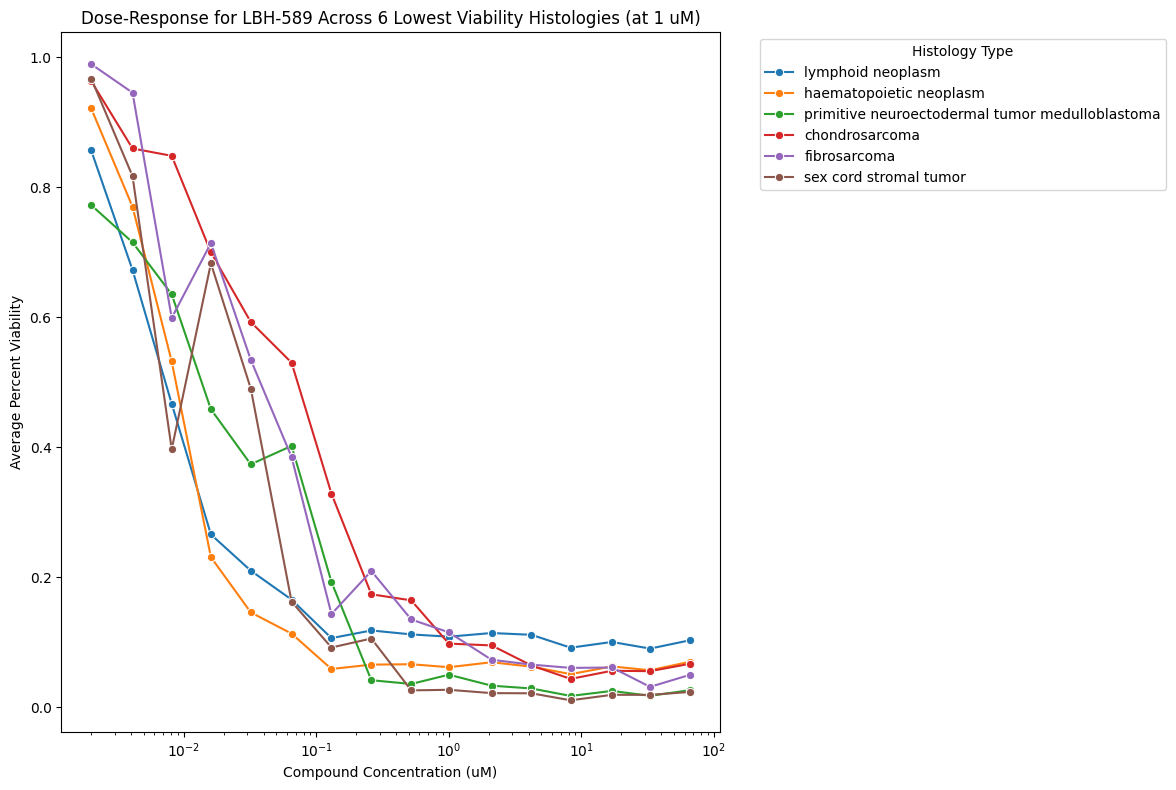

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

single_compound_name = 'LBH-589'
single_compound_id = compound_df[compound_df['cpd_name'] == single_compound_name]['master_cpd_id'].iloc[0]

compound_LBH589_all_histology_df = final_merged_df[
    (final_merged_df['master_cpd_id'] == single_compound_id)
].copy()
compound_LBH589_all_histology_df['ccle_primary_hist_cleaned'] = compound_LBH589_all_histology_df['ccle_primary_hist'].str.replace('_', ' ')

target_concentration = 1.0

df_at_target_conc = compound_LBH589_all_histology_df[
    np.isclose(compound_LBH589_all_histology_df['cpd_conc_umol'], target_concentration)
].copy()

avg_pv_at_target_conc_by_histology = df_at_target_conc.groupby('ccle_primary_hist_cleaned')['cpd_avg_pv'].mean().sort_values()

lowest_pv_histologies = avg_pv_at_target_conc_by_histology.head(6).index.tolist()

filtered_LBH589_histologies_df = compound_LBH589_all_histology_df[
    compound_LBH589_all_histology_df['ccle_primary_hist_cleaned'].isin(lowest_pv_histologies)
]

plt.figure(figsize=(12, 8))
sns.lineplot(
    data=filtered_LBH589_histologies_df,
    x='cpd_conc_umol',
    y='cpd_avg_pv',
    hue='ccle_primary_hist_cleaned',
    marker='o',
    errorbar=None
)
plt.xscale('log')
plt.xlabel('Compound Concentration (uM)')
plt.ylabel('Average Percent Viability')
plt.title(f'Dose-Response for {single_compound_name} Across 6 Lowest Viability Histologies (at 1 uM)')
plt.legend(title='Histology Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)
plt.tight_layout()
plt.show()

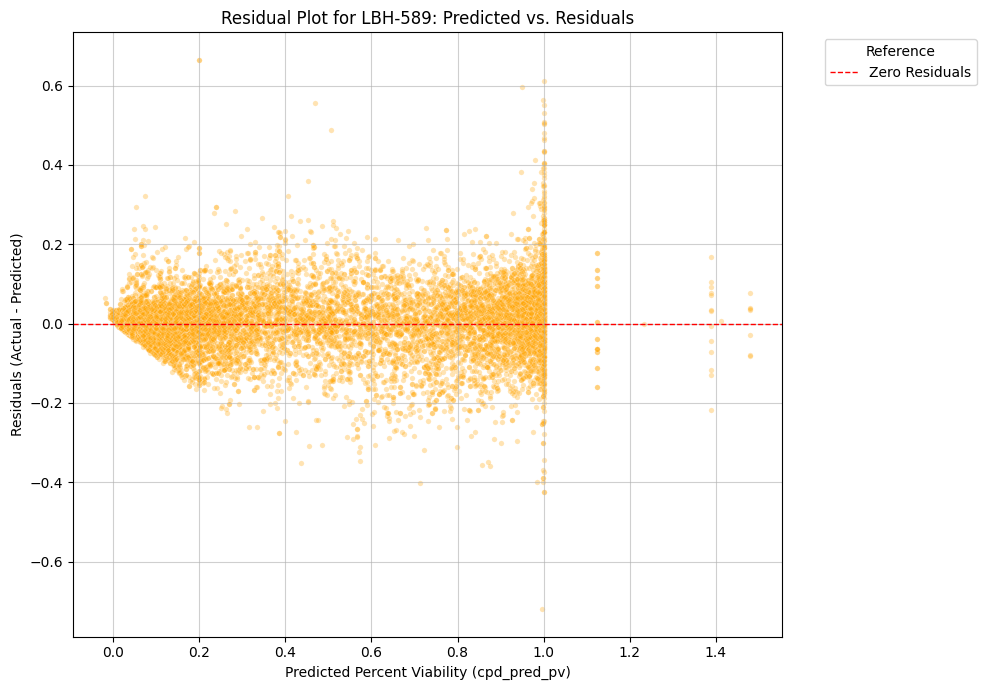

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

single_compound_name_lbh = 'LBH-589'
single_compound_id_lbh = compound_df[compound_df['cpd_name'] == single_compound_name_lbh]['master_cpd_id'].iloc[0]

plot_data_LBH589 = final_merged_df[final_merged_df['master_cpd_id'] == single_compound_id_lbh].copy()
plot_data_LBH589['residual'] = plot_data_LBH589['cpd_avg_pv'] - plot_data_LBH589['cpd_pred_pv']

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_data_LBH589,
    x='cpd_pred_pv',
    y='residual',
    alpha=0.3,
    s=15,
    color='orange' # Using the color previously defined for LBH-589
)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Residuals')
plt.xlabel('Predicted Percent Viability (cpd_pred_pv)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title(f'Residual Plot for {single_compound_name_lbh}: Predicted vs. Residuals')
plt.legend(title='Reference', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()